# Taller — Abandono de producto financiero
## Regresión logística en Python · Clase 9

**Curso:** Machine Learning aplicado a Economía y Finanzas · FCEA · 2026-2

**Estudiante:** Sebastián Rojas

Una entidad de banca de personas quiere pasar de la tasa agregada de abandono a una **probabilidad individual**. Cada fila de `abandono_producto_financiero.csv` es un cliente observado una vez (corte transversal) con su desenlace ya ocurrido: `abandono = 1` si cerró la relación con el banco y `abandono = 0` si permanece.

Es la misma familia de modelos que en la Clase 8 (crédito alemán), con otro desenlace:

$$
P(\texttt{abandono}=1 \mid x) = \Lambda(x\beta) = \frac{e^{x\beta}}{1+e^{x\beta}} \in (0,1)
$$

Los coeficientes del logit están en **log-odds**; $e^{\beta_j}$ es el *odds ratio*. OR $>1$: factor de **riesgo** (más abandono). OR $<1$: factor **protector**.

Las respuestas a las preguntas 1–21 están en celdas Markdown debajo de cada bloque de código, con las cifras de esta corrida.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy import build_design_matrices
from scipy import stats
from scipy.stats import chi2_contingency

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

CSV = "abandono_producto_financiero.csv"

if not Path(CSV).exists():
    raise FileNotFoundError(f"No está {CSV}. Déjelo junto a este notebook.")

# 1. Estructura de los datos

In [2]:
banco = pd.read_csv(CSV, encoding="utf-8")
banco.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [3]:
banco.columns.tolist()

['numero_fila',
 'id_cliente',
 'apellido',
 'puntaje_crediticio',
 'pais',
 'sexo',
 'edad',
 'antiguedad',
 'saldo',
 'numero_productos',
 'tiene_tarjeta',
 'miembro_activo',
 'salario_estimado',
 'abandono']

In [4]:
banco.shape

(10000, 14)

In [5]:
banco.dtypes

numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64
dtype: object

In [6]:
banco.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
numero_fila,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
id_cliente,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
apellido,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
puntaje_crediticio,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
pais,10000,3,Francia,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexo,10000,2,Hombre,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
antiguedad,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
saldo,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
numero_productos,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


In [7]:
# Faltantes y filas duplicadas
pd.Series({"valores faltantes": banco.isna().sum().sum(),
           "filas duplicadas": banco.duplicated().sum()})

valores faltantes    0
filas duplicadas     0
dtype: int64

Se quitan los identificadores (`numero_fila`, `id_cliente`, `apellido`): distinguen filas, no explican el abandono. `pais` y `sexo` pasan a `category` con los niveles del diccionario, en ese orden; así `C(pais)` toma **Francia** como referencia y `C(sexo)` toma **Mujer**. `abandono` queda como entero 0/1.

In [8]:
datos = banco.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

datos["pais"] = pd.Categorical(datos["pais"], categories=["Francia", "Alemania", "España"])
datos["sexo"] = pd.Categorical(datos["sexo"], categories=["Mujer", "Hombre"])
datos["abandono"] = datos["abandono"].astype(int)

datos.dtypes

puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

In [9]:
# Niveles (el primero es la referencia) y control de que ningún valor quedó por fuera
print(datos["pais"].cat.categories.tolist())
print(datos["sexo"].cat.categories.tolist())
datos[["pais", "sexo"]].isna().sum()

['Francia', 'Alemania', 'España']
['Mujer', 'Hombre']


pais    0
sexo    0
dtype: int64

In [10]:
cuantitativas = ["puntaje_crediticio", "edad", "antiguedad", "saldo",
                 "numero_productos", "salario_estimado"]
categoricas_binarias = ["pais", "sexo", "tiene_tarjeta", "miembro_activo", "abandono"]

pd.Series({
    "columnas en la base cruda": banco.shape[1],
    "columnas para el modelo": datos.shape[1],
    "predictores (x)": datos.shape[1] - 1,
    "cuantitativas": len(cuantitativas),
    "categóricas o binarias (con abandono)": len(categoricas_binarias),
})

columnas en la base cruda                14
columnas para el modelo                  11
predictores (x)                          10
cuantitativas                             6
categóricas o binarias (con abandono)     5
dtype: int64

### Respuestas — sección 1

**1. Variables en la base cruda y en el modelo.** La base cruda tiene **10 000 filas y 14 columnas**. Al quitar los tres identificadores (`numero_fila`, `id_cliente`, `apellido`) quedan **11 columnas para el modelo**: 10 predictores $x$ y la respuesta `abandono`. No hay valores faltantes ni filas duplicadas.

**2. Cuantitativas.** **6**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` (conteo entero de 1 a 4, que el diccionario trata como continuo) y `salario_estimado`.

**3. Categóricas o binarias.** **5**: `pais` (3 niveles), `sexo` (2 niveles), `tiene_tarjeta` (0/1), `miembro_activo` (0/1) y la respuesta `abandono` (0/1). En total, 6 + 5 = 11.

**4. Qué implica esta mezcla para el logit en Python.**
- Las cuantitativas entran tal cual: su coeficiente es el cambio en log-odds por **una unidad** (un año, un punto, una unidad monetaria). Por eso el OR de `saldo` o `salario_estimado` va a salir ≈ 1: una unidad monetaria es un cambio mínimo, y conviene leerlos por 10 000 o 50 000.
- Las binarias 0/1 ya son dummies: entran sin `C()` y su coeficiente compara 1 contra 0.
- `pais` y `sexo` son texto. Con `C(pais)` y `C(sexo)`, la fórmula de `statsmodels` (patsy) crea sola $k-1$ dummies y deja como referencia el **primer nivel** de la categoría (Francia y Mujer). Salen 2 coeficientes de país (Alemania, España) y 1 de sexo (Hombre), cada uno leído contra la referencia.
- Con dummies hechas a mano (`pd.get_dummies`) hay que elegir y quitar la referencia (si entran las tres dummies de país junto con el intercepto hay colinealidad perfecta: la trampa de las dummies) y repetir exactamente la misma codificación en test y en los perfiles. Con `C()` y categorías fijas, `predict` aplica sola la misma codificación a datos nuevos.

# 2. Descriptivo univariado

In [11]:
datos["abandono"].value_counts()

abandono
0    7963
1    2037
Name: count, dtype: int64

In [12]:
datos["abandono"].value_counts(normalize=True)

abandono
0    0.7963
1    0.2037
Name: proportion, dtype: float64

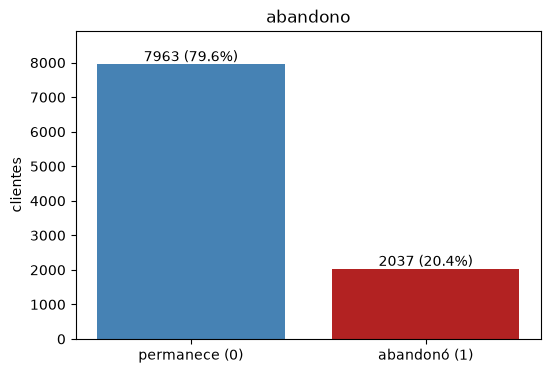

In [13]:
conteo = datos["abandono"].value_counts().sort_index()
plt.bar(["permanece (0)", "abandonó (1)"], conteo.values, color=["steelblue", "firebrick"])
for i, v in enumerate(conteo.values):
    plt.text(i, v + 80, f"{v} ({v / conteo.sum():.1%})", ha="center")
plt.ylim(0, conteo.max() * 1.12)
plt.ylabel("clientes")
plt.title("abandono")
plt.show()

In [14]:
datos[["edad", "puntaje_crediticio", "saldo", "salario_estimado"]].describe()

,edad,puntaje_crediticio,saldo,salario_estimado
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,38.921800,650.528800,76485.889288,100090.239881
std,10.487806,96.653299,62397.405202,57510.492818
min,18.000000,350.000000,0.000000,11.580000
25%,32.000000,584.000000,0.000000,51002.110000
50%,37.000000,652.000000,97198.540000,100193.915000
75%,44.000000,718.000000,127644.240000,149388.247500
max,92.000000,850.000000,250898.090000,199992.480000


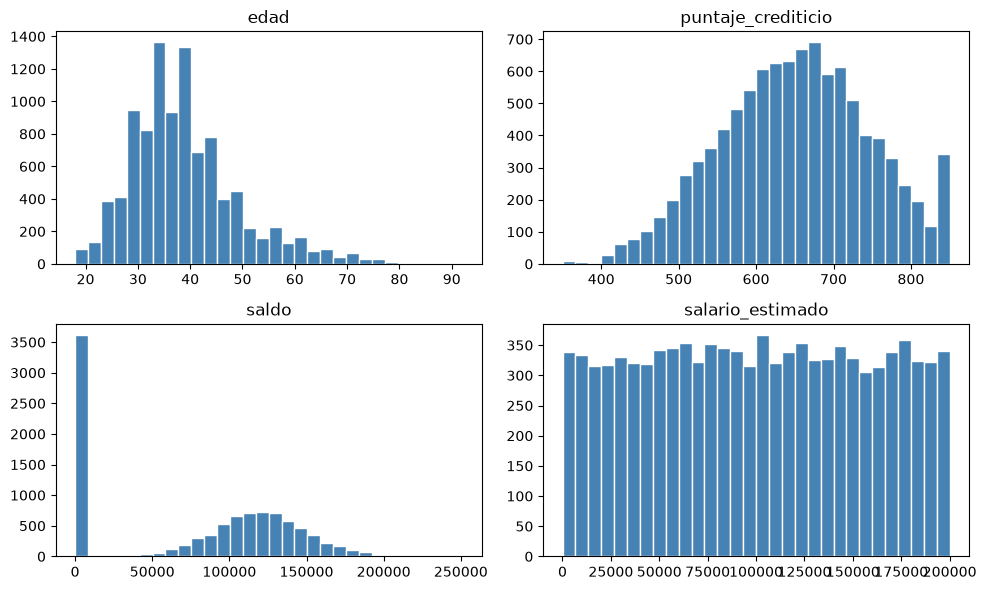

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.ravel(), ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]):
    ax.hist(datos[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [16]:
# El histograma de saldo tiene una barra enorme en 0
pd.Series({"proporción con saldo = 0": (datos["saldo"] == 0).mean(),
           "mediana del saldo si > 0": datos.loc[datos["saldo"] > 0, "saldo"].median()})

proporción con saldo = 0         0.3617
mediana del saldo si > 0    119839.6900
dtype: float64

Tablas de frecuencia de las categóricas:

In [17]:
def tabla_frecuencias(col):
    return pd.DataFrame({
        "n": datos[col].value_counts().sort_index(),
        "proporción": datos[col].value_counts(normalize=True).sort_index().round(4),
    })

tabla_frecuencias("pais")

,n,proporción
pais,,
Francia,5014,0.5014
Alemania,2509,0.2509
España,2477,0.2477


In [18]:
tabla_frecuencias("sexo")

,n,proporción
sexo,,
Mujer,4543,0.4543
Hombre,5457,0.5457


In [19]:
tabla_frecuencias("numero_productos")

,n,proporción
numero_productos,,
1,5084,0.5084
2,4590,0.4590
3,266,0.0266
4,60,0.0060


In [20]:
tabla_frecuencias("miembro_activo")

,n,proporción
miembro_activo,,
0,4849,0.4849
1,5151,0.5151


Un clasificador ingenuo que diga «permanece» (0) para todos los clientes:

In [21]:
pred_ingenua = np.zeros(len(datos), dtype=int)
pd.Series({
    "accuracy": (pred_ingenua == datos["abandono"]).mean(),
    "abandonos detectados": int(((pred_ingenua == 1) & (datos["abandono"] == 1)).sum()),
    "abandonos reales": int(datos["abandono"].sum()),
})

accuracy                   0.7963
abandonos detectados       0.0000
abandonos reales        2037.0000
dtype: float64

### Respuestas — sección 2

**Lectura de las $x$.**
- `edad`: media 38.9 y mediana 37 años, con cola a la derecha (hasta 92). La mitad central está entre 32 y 44 años.
- `puntaje_crediticio`: casi simétrico alrededor de 650 (rango 350–850), con una acumulación en el tope de 850 (233 clientes).
- `saldo`: el **36.2 %** de los clientes tiene saldo exactamente 0; el resto forma una campana alrededor de 120 000 (mediana de los saldos positivos: 119 840). Son dos grupos distintos, no una sola distribución.
- `salario_estimado`: prácticamente uniforme entre 0 y 200 000 (media ≈ 100 090).
- `pais`: Francia es la mitad de la base (50.1 %); Alemania (25.1 %) y España (24.8 %) se reparten el resto.
- `sexo`: 54.6 % hombres y 45.4 % mujeres.
- `numero_productos`: el 96.7 % tiene 1 o 2 productos; solo 266 clientes tienen 3 y 60 tienen 4.
- `miembro_activo`: mitad y mitad (51.5 % activos).

**5. Porcentaje de abandono y la trampa de la accuracy.** Abandonó el **20.37 %** de la base (2 037 de 10 000); permanece el 79.63 % (7 963). Las clases están desbalanceadas, cerca de 4 a 1.

Un clasificador que siempre diga «permanece» acierta con todos los que se quedan, así que su accuracy es **0.7963 (≈ 80 %)** sin usar ninguna $x$. Pero detecta **0 de los 2 037** abandonos: su sensibilidad es 0. Para el área de retención ese modelo no sirve, porque su trabajo es encontrar justo a la clase minoritaria. Por eso cualquier modelo hay que compararlo contra ese 80 % de base y, sobre todo, mirar la sensibilidad (sección 6), no solo la exactitud.

# 3. Bivariado con la respuesta

`edad`, `saldo` y `puntaje_crediticio` según `abandono`:

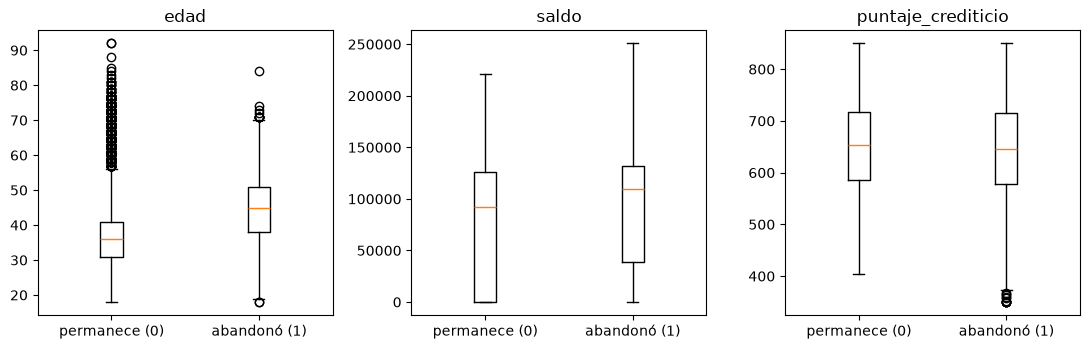

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, col in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [datos.loc[datos["abandono"] == k, col] for k in [0, 1]]
    ax.boxplot(grupos, tick_labels=["permanece (0)", "abandonó (1)"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [23]:
datos.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].median()

,edad,saldo,puntaje_crediticio
abandono,,,
0,36.0,92072.68,653.0
1,45.0,109349.29,646.0


In [24]:
datos.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].mean()

,edad,saldo,puntaje_crediticio
abandono,,,
0,37.408389,72745.296779,651.853196
1,44.837997,91108.539337,645.351497


In [25]:
# Tasa de abandono por tramo de edad
datos.groupby(pd.cut(datos["edad"], [17, 30, 40, 50, 60, 92]), observed=True)["abandono"].agg(["mean", "size"])

,mean,size
edad,,
"(17, 30]",0.075203,1968
"(30, 40]",0.120872,4451
"(40, 50]",0.339655,2320
"(50, 60]",0.562108,797
"(60, 92]",0.247845,464


In [26]:
# El saldo tiene muchos ceros: ¿cómo se reparten entre los dos grupos?
pd.DataFrame({
    "proporción con saldo = 0": datos.groupby("abandono")["saldo"].apply(lambda s: (s == 0).mean()),
    "mediana del saldo si > 0": datos.loc[datos["saldo"] > 0].groupby("abandono")["saldo"].median(),
})

,proporción con saldo = 0,mediana del saldo si > 0
abandono,,
0,0.391435,119791.215
1,0.245459,119948.090


In [27]:
# Tasa de abandono con y sin saldo
datos.groupby(datos["saldo"].gt(0).rename("saldo > 0"))["abandono"].mean()

saldo > 0
False    0.138236
True     0.240796
Name: abandono, dtype: float64

Tablas cruzadas y prueba ji-cuadrado de independencia contra `abandono`. Se imprime el conteo, la tasa de abandono por fila y el resultado de la prueba.

In [28]:
tab_activo = pd.crosstab(datos["miembro_activo"], datos["abandono"])
print(tab_activo)
print(pd.crosstab(datos["miembro_activo"], datos["abandono"], normalize="index").round(4))
ji2, p, gl, esperado = chi2_contingency(tab_activo)
print("ji2 =", round(ji2, 2), "| gl =", gl, "| p =", p)

abandono           0     1
miembro_activo            
0               3547  1302
1               4416   735
abandono             0       1
miembro_activo                
0               0.7315  0.2685
1               0.8573  0.1427
ji2 = 242.99 | gl = 1 | p = 8.785858269303703e-55


In [29]:
tab_productos = pd.crosstab(datos["numero_productos"], datos["abandono"])
print(tab_productos)
print(pd.crosstab(datos["numero_productos"], datos["abandono"], normalize="index").round(4))
ji2, p, gl, esperado = chi2_contingency(tab_productos)
print("ji2 =", round(ji2, 2), "| gl =", gl, "| p =", p)
print("menor frecuencia esperada =", esperado.min().round(1))

abandono             0     1
numero_productos            
1                 3675  1409
2                 4242   348
3                   46   220
4                    0    60
abandono               0       1
numero_productos                
1                 0.7229  0.2771
2                 0.9242  0.0758
3                 0.1729  0.8271
4                 0.0000  1.0000
ji2 = 1503.63 | gl = 3 | p = 0.0
menor frecuencia esperada = 12.2


In [30]:
tab_pais = pd.crosstab(datos["pais"], datos["abandono"])
print(tab_pais)
print(pd.crosstab(datos["pais"], datos["abandono"], normalize="index").round(4))
ji2, p, gl, esperado = chi2_contingency(tab_pais)
print("ji2 =", round(ji2, 2), "| gl =", gl, "| p =", p)

abandono     0    1
pais               
Francia   4204  810
Alemania  1695  814
España    2064  413
abandono       0       1
pais                    
Francia   0.8385  0.1615
Alemania  0.6756  0.3244
España    0.8333  0.1667
ji2 = 301.26 | gl = 2 | p = 3.8303176053541544e-66


Con 10 000 filas casi cualquier diferencia sale significativa, así que el $p$ no alcanza para ordenar las variables. Para comparar la **fuerza** de la asociación se usa la V de Cramér, $V=\sqrt{\chi^2 / \big(n\,(\min(r,c)-1)\big)}$, que va de 0 a 1. Las continuas se cortan en quintiles para aplicarles la misma prueba (el saldo queda en 4 tramos, porque el 36 % de ceros ocupa más de un quintil).

In [31]:
def resumen_ji2(serie):
    tab = pd.crosstab(serie, datos["abandono"])
    ji2, p, gl, _ = chi2_contingency(tab)
    v = np.sqrt(ji2 / (tab.values.sum() * (min(tab.shape) - 1)))
    return pd.Series({"ji2": ji2, "gl": gl, "p": p, "V_Cramer": v})

candidatas = {
    "numero_productos": datos["numero_productos"],
    "pais": datos["pais"],
    "miembro_activo": datos["miembro_activo"],
    "sexo": datos["sexo"],
    "tiene_tarjeta": datos["tiene_tarjeta"],
    "edad (quintiles)": pd.qcut(datos["edad"], 5),
    "saldo (cuantiles)": pd.qcut(datos["saldo"], 5, duplicates="drop"),
    "puntaje (quintiles)": pd.qcut(datos["puntaje_crediticio"], 5),
}
pd.DataFrame({k: resumen_ji2(s) for k, s in candidatas.items()}).T.sort_values("V_Cramer", ascending=False)

,ji2,gl,p,V_Cramer
numero_productos,1503.629362,3.0,0.000000e+00,0.387767
edad (quintiles),1242.928486,4.0,7.863629e-268,0.352552
pais,301.255337,2.0,3.830318e-66,0.173567
miembro_activo,242.985342,1.0,8.785858e-55,0.155880
saldo (cuantiles),145.053543,3.0,3.073910e-31,0.120438
sexo,112.918571,1.0,2.248210e-26,0.106263
puntaje (quintiles),11.610562,4.0,2.049484e-02,0.034074
tiene_tarjeta,0.471338,1.0,4.923724e-01,0.006865


### Respuestas — sección 3

**6. Edad.** Es la diferencia más visible en los boxplots: la caja de quienes abandonan está corrida hacia arriba. La mediana es **45 años** en quienes se fueron frente a **36** en quienes permanecen (medias 44.8 y 37.4). El rango intercuartílico es 38–51 años contra 31–41, así que las cajas casi no se solapan. En los que permanecen, los mayores de 60 aparecen como atípicos; en los que se van, esas edades son parte normal de la distribución. La relación no es lineal: la tasa de abandono sube de 7.5 % (hasta 30 años) a 12.1 % (31–40), 34.0 % (41–50) y **56.2 %** (51–60), y vuelve a bajar a 24.8 % después de los 60.

**7. Saldo y puntaje crediticio.**
- `saldo`: quien abandona tiene **más** saldo, no menos: mediana 109 349 frente a 92 073 (medias 91 109 y 72 745). La diferencia viene sobre todo de las cuentas en cero: el 39.1 % de los que permanecen tiene saldo 0, frente al 24.5 % de los que se van. Entre los clientes con saldo positivo las medianas son casi idénticas (119 791 y 119 948). En otras palabras, el cliente con cuenta en cero abandona menos (13.8 % contra 24.1 % de los que tienen saldo); una vez hay saldo, el monto no separa a los grupos.
- `puntaje_crediticio`: las dos cajas son prácticamente iguales: mediana 646 en quienes se van y 653 en quienes se quedan, con rangos iguales. Son 7 puntos en una escala de 350 a 850. Con 10 000 datos la diferencia alcanza a ser significativa (quintiles: $p = 0.02$), pero la V de Cramér es 0.03: una asociación muy débil.

**8. Miembro activo.** Sí. Entre los **activos** abandona el **14.3 %** (735 de 5 151); entre los **inactivos**, el **26.9 %** (1 302 de 4 849): casi el doble. La ji-cuadrado da $\chi^2 = 242.99$ con 1 gl y $p \approx 9 \times 10^{-55}$: se rechaza la independencia. Ser miembro activo se asocia con menos abandono.

**9. Número de productos.** No: la relación **no es monótona**. La tasa de abandono es 27.7 % con 1 producto, cae a **7.6 %** con 2 y se dispara a **82.7 %** con 3 y a **100 %** con 4 (los 60 clientes con 4 productos se fueron). El segundo producto se asocia con retención; el tercero y el cuarto aparecen en clientes que se van (por ejemplo, productos vendidos a clientes que ya estaban insatisfechos, o productos abiertos justo antes de cerrar la relación). Es la ji-cuadrado más alta: $\chi^2 = 1503.63$, 3 gl, $p \approx 0$ (la menor frecuencia esperada es 12.2 > 5, así que la prueba es válida). Ojo para el logit: si `numero_productos` entra como una sola variable continua, un solo coeficiente no puede capturar esta forma de U.

**10. Variable con mayor relación con el abandono: `numero_productos`, seguida de cerca por `edad`.** En el resumen, todas las variables menos `tiene_tarjeta` ($p = 0.49$) rechazan la independencia, así que el $p$ no permite ordenarlas; la V de Cramér sí: `numero_productos` 0.388, `edad` (quintiles) 0.353, `pais` 0.174, `miembro_activo` 0.156, `saldo` 0.120, `sexo` 0.106, `puntaje_crediticio` 0.034 y `tiene_tarjeta` 0.007. Entre las continuas, la edad es la única con boxplots claramente separados (medianas 45 contra 36). En país, Alemania tiene el doble de abandono (32.4 %) que Francia (16.2 %) y España (16.7 %).

# 4. De la recta al logit

Una $x$ continua (`edad`) y la respuesta 0/1. Primero `smf.ols` (modelo lineal de probabilidad) y después `smf.logit`, sobre toda la base, como en la Clase 8.

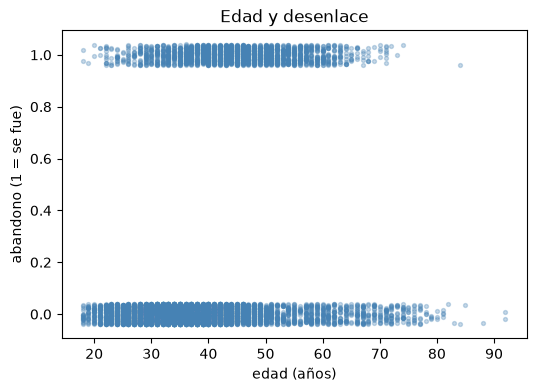

In [32]:
rng = np.random.default_rng(1)
y_jit = datos["abandono"] + rng.uniform(-0.04, 0.04, len(datos))
plt.scatter(datos["edad"], y_jit, c="steelblue", s=8, alpha=0.3)
plt.xlabel("edad (años)")
plt.ylabel("abandono (1 = se fue)")
plt.title("Edad y desenlace")
plt.show()

In [33]:
ols = smf.ols("abandono ~ edad", data=datos).fit()
print(ols.params)

Intercept   -0.222782
edad         0.010957
dtype: float64


In [34]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:               abandono   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     886.1
Date:                Thu, 24 Sep 2026   Prob (F-statistic):          1.24e-186
Time:                        14:55:58   Log-Likelihood:                -4670.4
No. Observations:               10000   AIC:                             9345.
Df Residuals:                    9998   BIC:                             9359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2228      0.015    -15.014      0.0

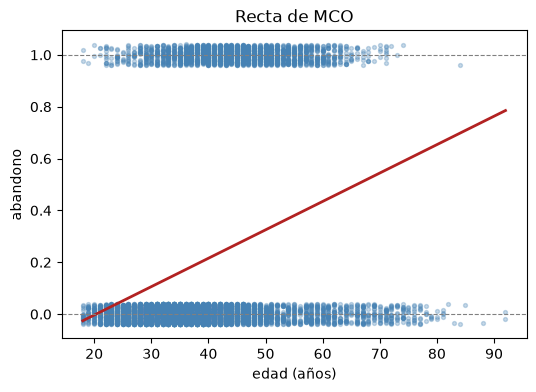

In [35]:
x_line = np.linspace(datos["edad"].min(), datos["edad"].max(), 50)
plt.scatter(datos["edad"], y_jit, c="steelblue", s=8, alpha=0.3)
plt.plot(x_line, ols.params["Intercept"] + ols.params["edad"] * x_line, color="firebrick", lw=2)
plt.axhline(0, color="gray", lw=0.8, ls="--")
plt.axhline(1, color="gray", lw=0.8, ls="--")
plt.xlabel("edad (años)")
plt.ylabel("abandono")
plt.title("Recta de MCO")
plt.show()

In [36]:
# La recta leída como "probabilidad"
print("ajustado mínimo:", round(ols.fittedvalues.min(), 4))
print("clientes con ajustado < 0:", (ols.fittedvalues < 0).sum())
print("edad en la que la recta vale 0:", round(-ols.params["Intercept"] / ols.params["edad"], 1))
print("edad en la que la recta vale 1:", round((1 - ols.params["Intercept"]) / ols.params["edad"], 1))
ols.predict(pd.DataFrame({"edad": [18, 40, 60, 92]}))

ajustado mínimo: -0.0255
clientes con ajustado < 0: 89
edad en la que la recta vale 0: 20.3
edad en la que la recta vale 1: 111.6


0   -0.025549
1    0.215514
2    0.434662
3    0.785299
dtype: float64

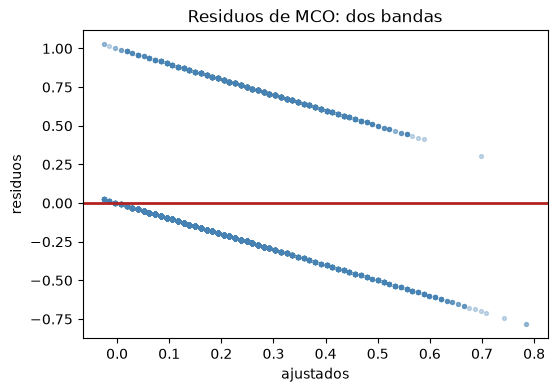

In [37]:
plt.scatter(ols.fittedvalues, ols.resid, c="steelblue", s=8, alpha=0.3)
plt.axhline(0, color="firebrick", lw=2)
plt.xlabel("ajustados")
plt.ylabel("residuos")
plt.title("Residuos de MCO: dos bandas")
plt.show()

## El logit simple

Misma $x$, estimada con `smf.logit`.

In [38]:
fit = smf.logit("abandono ~ edad", data=datos).fit(disp=False)
print(fit.params)

Intercept   -3.928603
edad         0.062945
dtype: float64


In [39]:
print(fit.summary())

                           Logit Regression Results                           
Dep. Variable:               abandono   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.07505
Time:                        14:55:58   Log-Likelihood:                -4675.5
converged:                       True   LL-Null:                       -5054.9
Covariance Type:            nonrobust   LLR p-value:                5.077e-167
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9286      0.103    -38.096      0.000      -4.131      -3.726
edad           0.0629      0.002     26.614      0.000       0.058       0.068


In [40]:
np.exp(fit.params)

Intercept    0.019671
edad         1.064968
dtype: float64

De log-odds a probabilidad para un cliente de 40 años:

In [41]:
b0 = fit.params["Intercept"]
b1 = fit.params["edad"]
eta = b0 + b1 * 40
odds = np.exp(eta)
p = odds / (1 + odds)
pd.Series({"log_odds": eta, "odds": odds, "P_abandono": p,
           "con predict()": fit.predict(pd.DataFrame({"edad": [40]})).iloc[0]})

log_odds        -1.410810
odds             0.243946
P_abandono       0.196106
con predict()    0.196106
dtype: float64

In [42]:
# OR por 10 años y probabilidad en otras edades
print("OR por 10 años:", round(np.exp(10 * b1), 4))
fit.predict(pd.DataFrame({"edad": [30, 40, 50, 60]}))

OR por 10 años: 1.8766


0    0.115040
1    0.196106
2    0.314027
3    0.462095
dtype: float64

La curva en S: `predict` devuelve $P(\texttt{abandono})$, siempre entre 0 y 1.

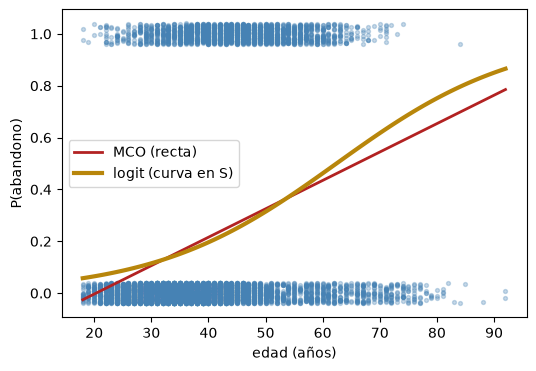

In [43]:
grid = pd.DataFrame({"edad": np.linspace(datos["edad"].min(), datos["edad"].max(), 100)})
grid["p"] = fit.predict(grid)

plt.scatter(datos["edad"], y_jit, c="steelblue", s=8, alpha=0.3)
plt.plot(x_line, ols.params["Intercept"] + ols.params["edad"] * x_line,
         color="firebrick", lw=2, label="MCO (recta)")
plt.plot(grid["edad"], grid["p"], color="darkgoldenrod", lw=3, label="logit (curva en S)")
plt.xlabel("edad (años)")
plt.ylabel("P(abandono)")
plt.legend()
plt.show()

### Respuestas — sección 4

**11. Por qué la recta de mínimos cuadrados no se puede leer como probabilidad.** El modelo lineal ajusta $\hat{y} = -0.2228 + 0.01096\,\texttt{edad}$, y nada lo obliga a quedarse dentro de $[0,1]$:
- Para los clientes de 18 a 20 años el ajuste es **negativo** (−0.026 a los 18): en esta base hay **89 clientes** con una "probabilidad" menor que 0. La recta cruza el 0 a los 20.3 años y, si se extrapola, pasaría de 1 a los 111.6 años.
- Impone un efecto marginal constante: cada año suma 1.1 puntos porcentuales, tenga el cliente 20 o 70 años. Los datos dicen otra cosa (sección 3): el abandono se acelera entre los 40 y los 60 y cae después.
- Como $y$ solo vale 0 o 1, los residuos forman dos bandas y su varianza cambia con $x$ (heterocedasticidad por construcción), así que los errores estándar de MCO no son los correctos.

El logit pasa $x\beta$ por $\Lambda(\cdot)$, que siempre devuelve un valor en $(0,1)$ y deja que el efecto de la edad sobre la probabilidad cambie según el nivel de la edad.

**12. Intercepto, coeficiente y odds ratio del logit simple.** Sobre las 10 000 filas: intercepto $\hat\beta_0 = -3.9286$ y coeficiente de edad $\hat\beta_{\text{edad}} = 0.0629$ ($p < 0.001$). El odds ratio es $e^{0.0629} =$ **1.065**.

*En lenguaje de negocio:* cada año adicional de edad multiplica por 1.065 las odds de que el cliente cierre su relación con el banco, es decir, las sube cerca de **6.5 %**; diez años más casi las duplican (OR por 10 años = 1.88). La edad es un factor de **riesgo**.

**13. $P(\texttt{abandono})$ para un cliente de 40 años.** $\eta = -3.9286 + 0.0629 \times 40 = -1.411$; odds $= e^{-1.411} = 0.244$; $P = 0.244 / 1.244 =$ **0.196 (19.6 %)**. `predict` da el mismo valor. Queda muy cerca de la tasa media de la base (20.4 %) porque 40 años está cerca de la edad media (38.9). Con el mismo modelo, a los 30 años la probabilidad es 11.5 % y a los 60, 46.2 %.